
# Unidad 2 — Análisis en Frecuencia (DFT y PSD)

En este notebook aprenderemos a analizar señales en el dominio de la frecuencia.

## Objetivos

- Aplicar la Transformada Discreta de Fourier (DFT)
- Visualizar espectros de frecuencia
- Calcular la Densidad Espectral de Potencia (PSD)
- Interpretar diferencias entre especies acústicas


In [1]:

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import librosa


In [2]:

DATA_DIR = Path("../data/audios")
clases = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])

print(clases)


['Batrachyla_leptopus', 'Batrachyla_taeniata', 'Calyptocephalella_gayi', 'Pleurodema_thaul', 'Porzana_spiloptera']


In [11]:
print("Especies disponibles:")
for c in clases:
    print("-", c)

Especies disponibles:
- Batrachyla_leptopus
- Batrachyla_taeniata
- Calyptocephalella_gayi
- Pleurodema_thaul
- Porzana_spiloptera


In [7]:

# Selección de especie y audio

# Elegir especie manualmente (cambia aquí)
especie = "Calyptocephalella_gayi"

# Ruta a la carpeta de la especie
ruta_especie = DATA_DIR / especie

# Obtener lista de archivos
archivos = list(ruta_especie.glob("*.wav"))

# Seleccionar uno (puedes cambiar el índice)
archivo = archivos[0]

# Cargar audio
y, sr = librosa.load(archivo, sr=None)

# Información clara
print(f"Especie seleccionada: {especie}")
print(f"Archivo: {archivo.name}")
print(f"Frecuencia de muestreo: {sr} Hz")
print(f"Duración: {len(y)/sr:.2f} s")


Especie seleccionada: Calyptocephalella_gayi
Archivo: audio362_label24.wav
Frecuencia de muestreo: 44100 Hz
Duración: 1.33 s



## Transformada de Fourier (DFT)


In [8]:

Y = np.fft.fft(y)
frequencies = np.fft.fftfreq(len(Y), d=1/sr)

# Solo parte positiva
mask = frequencies >= 0
frequencies = frequencies[mask]
magnitude = np.abs(Y[mask])


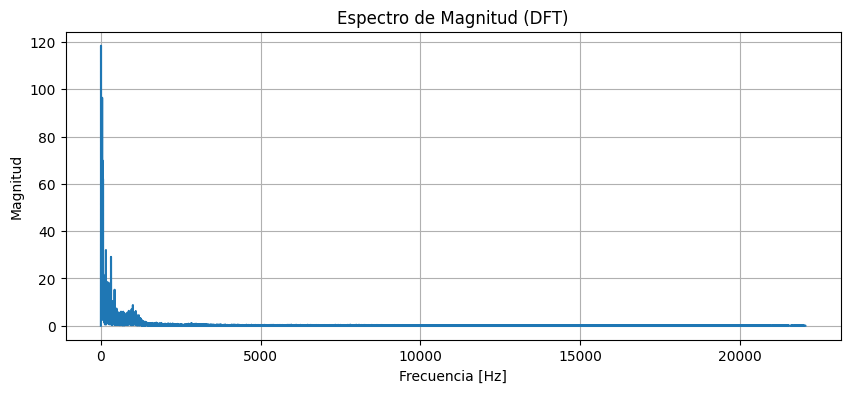

In [9]:

plt.figure(figsize=(10,4))
plt.plot(frequencies, magnitude)
plt.title("Espectro de Magnitud (DFT)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud")
plt.grid()
plt.show()



## 🔹 Densidad Espectral de Potencia (PSD)


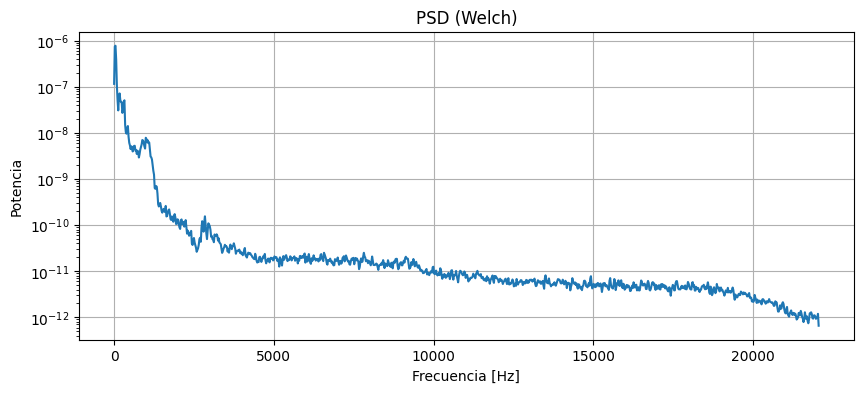

In [10]:

from scipy.signal import welch

f, psd = welch(y, sr, nperseg=2048)

plt.figure(figsize=(10,4))
plt.semilogy(f, psd)
plt.title("PSD (Welch)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Potencia")
plt.grid()
plt.show()



## Preguntas

1. ¿En qué frecuencias se concentra la energía?
2. ¿Cómo cambia el espectro entre especies?
3. ¿Qué diferencias observas entre DFT y PSD?
4. ¿Qué información nueva entrega el dominio de la frecuencia?


In [12]:
# PSD promedio por especie

from scipy.signal import welch
import numpy as np
import matplotlib.pyplot as plt
import librosa

# Parámetros
sr_target = 44100
nperseg = 4096

psd_promedio = {}

for especie in clases:
    archivos = list((DATA_DIR / especie).glob("*.wav"))
    psds = []

    for archivo in archivos:
        y, sr = librosa.load(archivo, sr=sr_target, mono=True)

        f, psd = welch(
            y,
            fs=sr_target,
            nperseg=nperseg
        )

        psds.append(psd)

    # Promediar PSD en escala lineal
    psd_mean = np.mean(psds, axis=0)
    psd_promedio[especie] = psd_mean

print("PSD promedio calculada para:")
for especie in psd_promedio:
    print("-", especie)

PSD promedio calculada para:
- Batrachyla_leptopus
- Batrachyla_taeniata
- Calyptocephalella_gayi
- Pleurodema_thaul
- Porzana_spiloptera


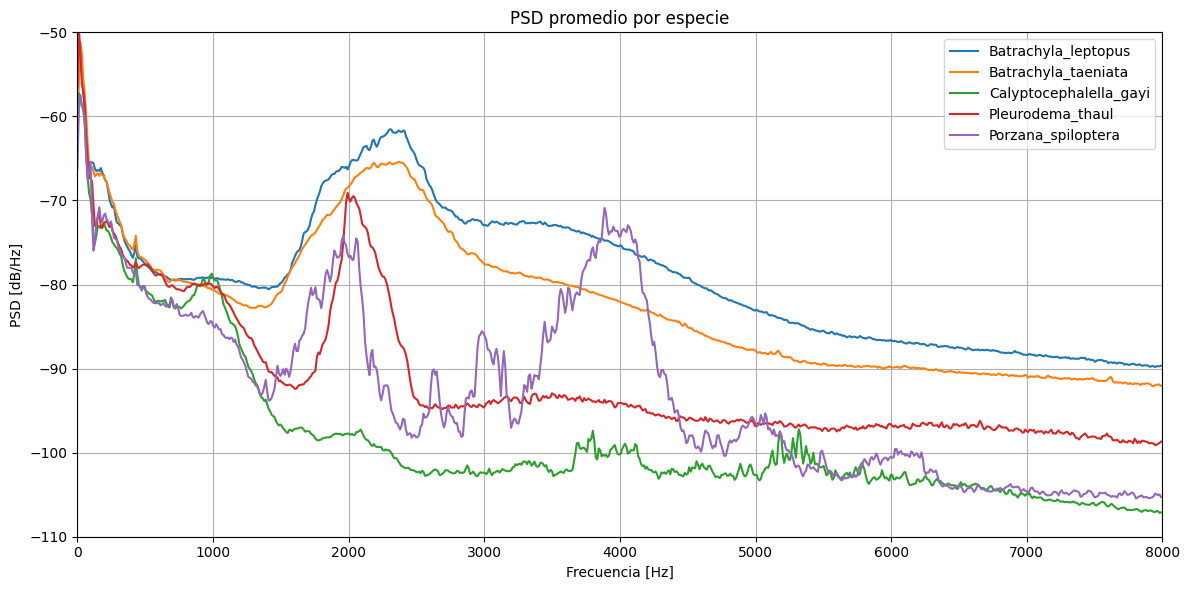

In [14]:
plt.figure(figsize=(12, 6))

for especie, psd_mean in psd_promedio.items():
    plt.plot(f, 10 * np.log10(psd_mean + 1e-12), label=especie)

plt.title("PSD promedio por especie")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [dB/Hz]")
plt.xlim(0, 8000)
plt.grid()
plt.legend()
plt.tight_layout()
plt.ylim(-110, -50)
plt.show()

### Cada curva representa cómo se distribuye la energía en frecuencia para cada especie.
### Esto es como una ‘firma acústica promedio’.

* Batrachyla leptopus (azul)
    → energía fuerte en ~2–3 kHz
* Batrachyla taeniata (naranjo)
    → similar, pero más suave (menos energía relativa)
* Pleurodema thaul (rojo)
    → pico más definido cerca de ~2 kHz
* Calyptocephalella gayi (verde)
    → mucho más “apagada” en altas frecuencias
* Porzana spiloptera (morado)
    → energía dominante en ~4 kHz

* Aunque las señales en el tiempo parecen complejas, en frecuencia aparecen patrones muy claros que permiten diferenciar especies.